# **Fase 02: Modelado, API y Despliegue**

**Objetivo:** Desarrollar una API multifuncional que prediga el éxito de un videojuego y permita hacer consultas complejas.

**Desarrollo de la API (ML Engineer, Data Scientist):**
    - Crear una aplicación con **FastAPI** que incluya los siguientes endpoints:  
    
      - `/predict`: Recibe los datos de un videojuego y devuelve la predicción del modelo.  
      
      - `/ask-text`: Recibe una pregunta en texto (ej. "¿Desarrollador con la mejor puntuación?"), la convierte a SQL usando un modelo de **Hugging Face**, consulta la base de datos y devuelve una respuesta en texto.  
      
      - `/ask-visual`: Recibe una pregunta orientada a visualización (ej. "Top 10 géneros por número de juegos"), consulta la base de datos y devuelve un gráfico generado con **Matplotlib/Seaborn**.

## 1. Configuración y conexión con los datos
Importar librerías necesarios y conectar con la base de datos de RDS 

In [1]:
# Importar librerías necesarias

import os
import io
import json
import re

import pandas as pd
import matplotlib.pyplot as plt

import psycopg2
from psycopg2.extras import RealDictCursor

import sys
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("Project root añadido a sys.path:", PROJECT_ROOT)



Project root añadido a sys.path: C:\Users\crisr\dev\rawg-aws-ml-analytics


In [2]:
# Conectar con la instancia de RDS
from utils.aws_secrets import get_rds_credentials

SECRET_NAME = os.getenv("DB_SECRET_NAME", "Postgre") 
DB_SCHEMA = os.getenv("DB_SCHEMA", "rawg")

def get_connection():
    creds = get_rds_credentials(SECRET_NAME) 
    return psycopg2.connect(
        host=creds["host"],
        port=int(creds["port"]),
        dbname=creds["dbname"],
        user=creds["username"],
        password=creds["password"],
        sslmode="require",
        connect_timeout=10,
        application_name="rawg-notebook",
    )


In [3]:
# Convertir respuestas de las queries (en SQL) a DataFrames o Diccionarios pasando por dos filtros de seguridad

FORBIDDEN = re.compile(r"(;|--|/\*|\*/|\b(insert|update|delete|drop|alter|create|truncate)\b)", re.IGNORECASE)

def _ensure_select_only(sql: str):
    s = sql.strip().lower()
    if not s.startswith("select"):
        raise ValueError("Solo SELECT permitido en este notebook helper.")
    if FORBIDDEN.search(s):
        raise ValueError("SQL bloqueado por seguridad (posible multi-statement o DDL/DML).")

def query_df(sql: str, params: dict | None = None) -> pd.DataFrame:
    _ensure_select_only(sql)
    with get_connection() as conn:
        return pd.read_sql_query(sql, conn, params=params)

def query_dicts(sql: str, params: dict | None = None) -> list[dict]:
    _ensure_select_only(sql)
    with get_connection() as conn:
        with conn.cursor(cursor_factory=RealDictCursor) as cur:
            cur.execute(sql, params)
            return [dict(r) for r in cur.fetchall()]


In [4]:
query_df("SELECT version() AS pg_version")


C:\Users\crisr\AppData\Local\Temp\ipykernel_24872\1584655591.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conn, params=params)


,pg_version
0,"PostgreSQL 17.6 on aarch64-unknown-linux-gnu, ..."


In [5]:
query_df(f"SELECT COUNT(*) AS n_games FROM {DB_SCHEMA}.games")


C:\Users\crisr\AppData\Local\Temp\ipykernel_24872\1584655591.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conn, params=params)


,n_games
0,137179


In [6]:
query_df(f"""
SELECT 
  MIN(released_ym) AS min_released,
  MAX(released_ym) AS max_released,
  COUNT(*) FILTER (WHERE released_ym IS NULL) AS null_released
FROM {DB_SCHEMA}.games
""")


C:\Users\crisr\AppData\Local\Temp\ipykernel_24872\1584655591.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conn, params=params)


,min_released,max_released,null_released
0,2016-01,2026-01,0


In [7]:
query_df(f"""
SELECT 'game_genres' AS table_name, COUNT(*) AS n FROM {DB_SCHEMA}.game_genres
UNION ALL
SELECT 'game_platforms', COUNT(*) FROM {DB_SCHEMA}.game_platforms
UNION ALL
SELECT 'game_tags', COUNT(*) FROM {DB_SCHEMA}.game_tags
UNION ALL
SELECT 'game_stores', COUNT(*) FROM {DB_SCHEMA}.game_stores
ORDER BY table_name
""")


C:\Users\crisr\AppData\Local\Temp\ipykernel_24872\1584655591.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conn, params=params)


,table_name,n
0,game_genres,245647
1,game_platforms,197613
2,game_stores,156184
3,game_tags,1975384


### A) Resolver ask-visual con modelos de clasificación de intenciones:
Clasificar intenciones en las queries realizadas con lenguaje natural entre opciones predefinidas en un catálogo llamado VISUALS.  

Pregunta → Clasificar intención → SQL predefinido → Gráfico

Usuario: "muéstrame los géneros más populares" ->  
MVP (Motor de intención básico) ó Modelo NLP (Hugging Face): Clasifica "top_genres" ->  
VISUALS["top_genres"]: SQL predefinido ->  
SELECT ...

Ventajas:  
- Seguridad: queries validadas
- Velocidad: No necesita generar SQL dinámicamente
- Confiabilidad: Siempre retorna el formato esperado (label, value)
- Control: se sabe exactamente qué queries se ejecutan
- Simplicidad: Fácil de manejar

Desventajas:  
- Limitado: Solo puede responder preguntas predefinidas en VISUALS
- Inflexible: No puede responder aquello que se pregunta y no tiene el filtro implementado
- Escalabilidad: Cada nueva pregunta requiere añadir entrada a VISUALS

In [8]:
# Catálogo con opciones prediseñadas para clasificar intenciones y realizar queries cerradas en la función "ask-visual" 
# Todas devuelven columnas label y value para que el plot sea genérico

VISUALS = {
    "top_genres": {
        "sql": f"""
            SELECT ge.genre_name AS label, COUNT(*)::bigint AS value
            FROM {DB_SCHEMA}.game_genres gg
            JOIN {DB_SCHEMA}.genres ge ON ge.genre_id = gg.genre_id
            GROUP BY ge.genre_name
            ORDER BY value DESC
            LIMIT %(limit)s
        """,
        "plot": "barh",
        "title": "Top géneros por número de juegos",
        "xlabel": "Nº de juegos",
        "ylabel": "Género",
    },
    "top_platforms": {
        "sql": f"""
            SELECT p.platform_name AS label, COUNT(*)::bigint AS value
            FROM {DB_SCHEMA}.game_platforms gp
            JOIN {DB_SCHEMA}.platforms p ON p.platform_id = gp.platform_id
            GROUP BY p.platform_name
            ORDER BY value DESC
            LIMIT %(limit)s
        """,
        "plot": "barh",
        "title": "Top plataformas por número de juegos",
        "xlabel": "Nº de juegos",
        "ylabel": "Plataforma",
    },
    "top_stores": {
        "sql": f"""
            SELECT s.store_name AS label, COUNT(*)::bigint AS value
            FROM {DB_SCHEMA}.game_stores gs
            JOIN {DB_SCHEMA}.stores s ON s.store_id = gs.store_id
            GROUP BY s.store_name
            ORDER BY value DESC
            LIMIT %(limit)s
        """,
        "plot": "barh",
        "title": "Top stores por número de juegos",
        "xlabel": "Nº de juegos",
        "ylabel": "Store",
    },
    "top_tags": {
        "sql": f"""
            SELECT t.tag_name AS label, COUNT(*)::bigint AS value
            FROM {DB_SCHEMA}.game_tags gt
            JOIN {DB_SCHEMA}.tags t ON t.tag_id = gt.tag_id
            GROUP BY t.tag_name
            ORDER BY value DESC
            LIMIT %(limit)s
        """,
        "plot": "barh",
        "title": "Top tags por número de juegos",
        "xlabel": "Nº de juegos",
        "ylabel": "Tag",
    },
    "games_by_release_month": {
        "sql": f"""
            SELECT released_ym AS label, COUNT(*)::bigint AS value
            FROM {DB_SCHEMA}.games
            WHERE released_ym IS NOT NULL
            GROUP BY released_ym
            ORDER BY released_ym
        """,
        "plot": "line",
        "title": "Juegos publicados por mes",
        "xlabel": "Mes (YYYY-MM)",
        "ylabel": "Nº de juegos",
    },
    "avg_rating_by_release_month": {
        "sql": f"""
            SELECT released_ym AS label, AVG(game_rating)::numeric(6,3) AS value
            FROM {DB_SCHEMA}.games
            WHERE released_ym IS NOT NULL AND game_rating IS NOT NULL
            GROUP BY released_ym
            ORDER BY released_ym
        """,
        "plot": "line",
        "title": "Rating medio por mes de publicación",
        "xlabel": "Mes (YYYY-MM)",
        "ylabel": "Rating medio",
    },
    "esrb_distribution": {
        "sql": f"""
            SELECT COALESCE(e.esrb_name, 'Unknown') AS label, COUNT(*)::bigint AS value
            FROM {DB_SCHEMA}.games g
            LEFT JOIN {DB_SCHEMA}.esrb_ratings e ON e.esrb_id = g.esrb_id
            GROUP BY COALESCE(e.esrb_name, 'Unknown')
            ORDER BY value DESC
        """,
        "plot": "barh",
        "title": "Distribución por ESRB",
        "xlabel": "Nº de juegos",
        "ylabel": "ESRB",
    },
    "top_playing": {
        "sql": f"""
            SELECT g.game_name AS label, s.playing::bigint AS value
            FROM {DB_SCHEMA}.games_status s
            JOIN {DB_SCHEMA}.games g ON g.game_id = s.game_id
            WHERE s.playing IS NOT NULL
            ORDER BY s.playing DESC
            LIMIT %(limit)s
        """,
        "plot": "barh",
        "title": "Top juegos por usuarios 'playing'",
        "xlabel": "Usuarios jugando",
        "ylabel": "Juego",
    },
}


## A.1) Solución motor de intención básico (MVP = Minium Viable Product):
Clasifica la intención de las preguntas en lenguaje natural del usuario a claves del diccionario VISUALS. Versión simplificada de lo que en producción sería un modelo NLP o LLM para clasificación de intenciones.

In [9]:
# Detector de intención (MVP)

def detect_intent(question: str) -> str:
    q = question.lower()

    if "esrb" in q or "edad" in q:
        return "esrb_distribution"
    if "plataforma" in q:
        return "top_platforms"
    if "store" in q or "tienda" in q:
        return "top_stores"
    if "tag" in q or "etiqueta" in q:
        return "top_tags"
    if "género" in q or "genero" in q:
        return "top_genres"
    if "playing" in q or "jugando" in q:
        return "top_playing"
    if "rating" in q or "puntuación" in q or "puntuacion" in q:
        return "avg_rating_by_release_month"
    if "mes" in q or "mensual" in q or "public" in q or "lanz" in q or "released" in q:
        return "games_by_release_month"

    return "No entiendo tu pregunta, prueba con: géneros, plataformas, tags..."


In [10]:
# Plot genérico (Matplotlib) + función ask-visual()

import matplotlib.dates as mdates

def plot_df(df: pd.DataFrame, kind: str, title: str, xlabel: str, ylabel: str):
    if df.empty:
        raise ValueError("La consulta no devolvió datos para graficar.")
    if not {"label", "value"}.issubset(df.columns):
        raise ValueError("Se esperaban columnas label y value.")

    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.set_title(title)

    if kind == "barh":
        df2 = df.sort_values("value", ascending=True)
        ax.barh(df2["label"].astype(str), df2["value"])
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
    elif kind == "line":
        df2 = df.copy()
        df2["label_dt"] = pd.to_datetime(df2["label"] + "-01")  # YYYY-MM -> fecha
    
        ax.plot(df2["label_dt"], df2["value"], marker="o")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
    
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))   # etiqueta cada 6 meses
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        ax.tick_params(axis="x", rotation=45)
    else:
        raise ValueError(f"Tipo de plot no soportado: {kind}")

    fig.tight_layout()
    plt.show()


def ask_visual(question: str, limit: int = 10, debug: bool = True) -> pd.DataFrame:
    intent = detect_intent(question)
    cfg = VISUALS[intent]

    params = {"limit": limit} if "%(limit)s" in cfg["sql"] else None
    df = query_df(cfg["sql"], params=params)

    if debug:
        print(f"Intent: {intent}")
        print(cfg["title"])
        print(df.head(10))

    plot_df(df, cfg["plot"], cfg["title"], cfg["xlabel"], cfg["ylabel"])
    return df


C:\Users\crisr\AppData\Local\Temp\ipykernel_24872\1584655591.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conn, params=params)


Intent: top_genres
Top géneros por número de juegos
        label  value
0       Indie  44290
1      Action  39109
2   Adventure  37187
3      Casual  29967
4  Simulation  19709
5         RPG  17370
6    Strategy  15855
7      Puzzle   9823
8  Platformer   8925
9     Shooter   5899


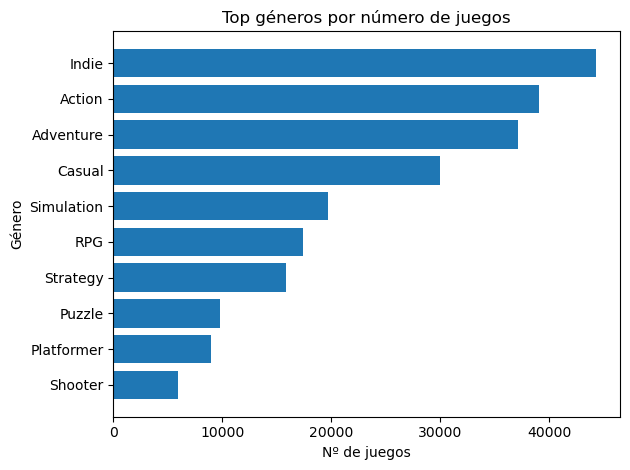

,label,value
0,Indie,44290
1,Action,39109
2,Adventure,37187
3,Casual,29967
4,Simulation,19709
5,RPG,17370
6,Strategy,15855
7,Puzzle,9823
8,Platformer,8925
9,Shooter,5899


In [11]:
# Prueba 1:

ask_visual("Top 10 géneros por número de juegos", limit=10)


C:\Users\crisr\AppData\Local\Temp\ipykernel_24872\1584655591.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conn, params=params)


Intent: esrb_distribution
Distribución por ESRB
            label   value
0         Unknown  123661
1    Everyone 10+    6293
2            Teen    3346
3          Mature    1549
4        Everyone    1416
5     Adults Only     862
6  Rating Pending      52


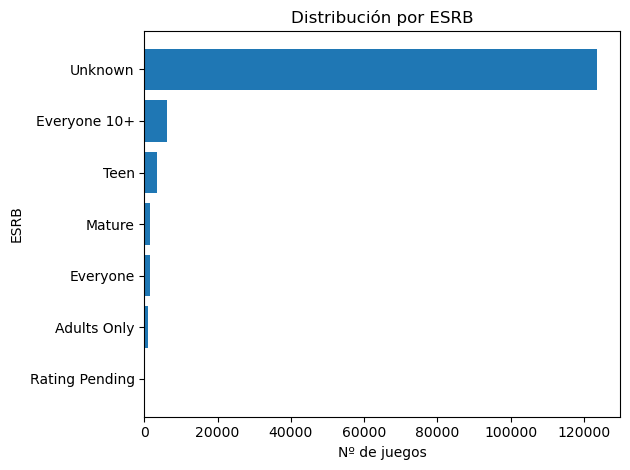

,label,value
0,Unknown,123661
1,Everyone 10+,6293
2,Teen,3346
3,Mature,1549
4,Everyone,1416
5,Adults Only,862
6,Rating Pending,52


In [12]:
# Prueba 2:

ask_visual("Distribución por ESRB", limit=20)


C:\Users\crisr\AppData\Local\Temp\ipykernel_24872\1584655591.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conn, params=params)


Intent: games_by_release_month
Juegos publicados por mes
     label  value
0  2016-01   1240
1  2016-02   1160
2  2016-03   1240
3  2016-04   1200
4  2016-05   1240
5  2016-06   1200
6  2016-07   1240
7  2016-08   1240
8  2016-09   1200
9  2016-10   1240


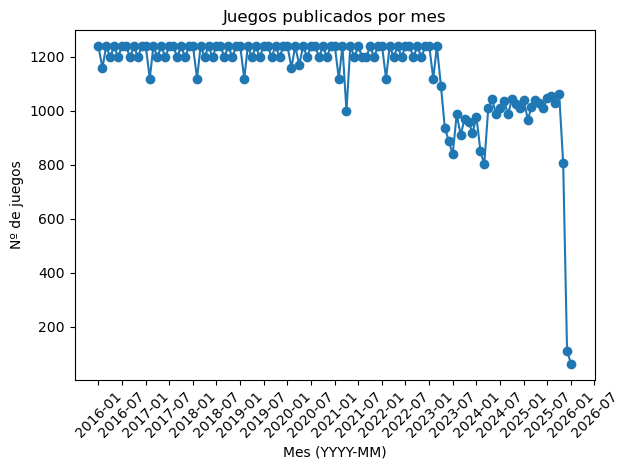

,label,value
0,2016-01,1240
1,2016-02,1160
2,2016-03,1240
3,2016-04,1200
4,2016-05,1240
...,...,...
116,2025-09,1029
117,2025-10,1063
118,2025-11,807
119,2025-12,110


In [13]:
# Prueba 3: 

ask_visual("Evolución mensual de juegos publicados", limit=200)  # limit no aplica aquí; lo ignora


## A.2) Solución para clasificación de intenciones con modelo de Hugging Face: paraphrase-MiniLM-L3-v2 
Este modelo genera embeddings semánticos de 384 dimensiones que permiten calcular la similitud coseno entre la pregunta del usuario y las descripciones de visualizaciones disponibles.

*Ventajas sobre regex*:
- Entiende sinónimos y paráfrasis (ej: "géneros" = "categorías" = "tipos")
- Funciona con preguntas en español e inglés
- Robusto ante errores ortográficos menores
- Escalable: añadir nuevas visualizaciones solo requiere agregar su descripción

*Especificaciones técnicas*:
- Modelo: sentence-transformers/paraphrase-MiniLM-L3-v2
- Tamaño: 80 MB
- Latencia: ~100-200ms por query
- Método: Cosine similarity en espacio de embeddings"


In [14]:

# === Instalación ===

!pip install sentence-transformers --quiet
print("Sentence-transformers instalado (modelo de Hugging Face)")

Sentence-transformers instalado (modelo de Hugging Face)


In [15]:

# === Cargar modelo de Hugging Face ===

from sentence_transformers import SentenceTransformer, util
import numpy as np

print("Descargando modelo de Hugging Face: paraphrase-MiniLM-L3-v2")
print("   Tamaño: ~80 MB (solo primera vez)")

# Cargar modelo ultraligero de Hugging Face
model = SentenceTransformer('paraphrase-MiniLM-L3-v2')

print("Modelo cargado correctamente\n")

# Información del modelo
print("Información del modelo:")
print(f"   • Nombre: paraphrase-MiniLM-L3-v2")
print(f"   • Fuente: Hugging Face Model Hub")
print(f"   • Tipo: Sentence Embeddings (similitud semántica)")
print(f"   • Dimensiones: 384")
print(f"   • Tamaño: 80 MB")

Descargando modelo de Hugging Face: paraphrase-MiniLM-L3-v2
   Tamaño: ~80 MB (solo primera vez)
Modelo cargado correctamente

Información del modelo:
   • Nombre: paraphrase-MiniLM-L3-v2
   • Fuente: Hugging Face Model Hub
   • Tipo: Sentence Embeddings (similitud semántica)
   • Dimensiones: 384
   • Tamaño: 80 MB


In [16]:

# === Precomputar embeddings de las visualizaciones disponibles ===


# Crear descripciones enriquecidas para mejor clasificación
visual_descriptions = {
    "top_genres": "géneros categorías tipos de juegos más populares",
    "top_platforms": "plataformas consolas sistemas PC Xbox PlayStation",
    "top_stores": "tiendas stores donde comprar Steam Epic",
    "top_tags": "tags etiquetas características multijugador acción",
    "esrb_distribution": "clasificación ESRB edad rating E T M todos adolescentes",
    "games_by_release_month": "juegos publicados lanzados por mes mensual fecha lanzamiento",
    "avg_rating_by_release_month": "rating puntuación calidad promedio evolución mensual temporal",
    "top_playing": "jugando ahora actualmente playing usuarios activos",
}

print("Precomputando embeddings de visualizaciones disponibles...")

# Codificar todas las descripciones (solo se hace una vez)
visual_keys = list(visual_descriptions.keys())
descriptions = list(visual_descriptions.values())

embeddings_cache = model.encode(
    descriptions,
    convert_to_tensor=True,
    show_progress_bar=True
)

print(f"{len(visual_keys)} visualizaciones codificadas\n")
print("Visualizaciones disponibles:")
for i, key in enumerate(visual_keys):
    print(f"   {i+1}. {key}: {VISUALS[key]['title']}")

Precomputando embeddings de visualizaciones disponibles...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

8 visualizaciones codificadas

Visualizaciones disponibles:
   1. top_genres: Top géneros por número de juegos
   2. top_platforms: Top plataformas por número de juegos
   3. top_stores: Top stores por número de juegos
   4. top_tags: Top tags por número de juegos
   5. esrb_distribution: Distribución por ESRB
   6. games_by_release_month: Juegos publicados por mes
   7. avg_rating_by_release_month: Rating medio por mes de publicación
   8. top_playing: Top juegos por usuarios 'playing'


In [18]:

# === Función detect_intent usando Hugging Face ===


def detect_intent_huggingface(question: str, threshold: float = 0.25) -> str:
    """
    Detector de intención usando modelo de Hugging Face
    
    Usa sentence-transformers (paraphrase-MiniLM-L3-v2) para calcular
    similitud semántica entre la pregunta del usuario y las descripciones
    de visualizaciones disponibles.
    
    Args:
        question (str): Pregunta del usuario en lenguaje natural
        threshold (float): Umbral mínimo de similitud (0.0 - 1.0)
        
    Returns:
        str: Clave de la visualización en VISUALS
        
    Example:
        >>> detect_intent_huggingface("muéstrame los géneros populares")
        'Detectado: top_genres (similitud: 78%)'
        'top_genres'
    """
    
    # Codificar pregunta del usuario
    question_embedding = model.encode(
        question,
        convert_to_tensor=True
    )
    
    # Calcular similitud coseno con todas las visualizaciones
    similarities = util.cos_sim(question_embedding, embeddings_cache)[0]
    
    # Obtener la visualización con mayor similitud
    best_idx = similarities.argmax().item()
    best_score = similarities[best_idx].item()
    best_visual = visual_keys[best_idx]
    
    # Mostrar resultado
    print(f"Detectado: {best_visual}")
    print(f"Similitud: {best_score:.1%}")
    print(f"Gráfico: {VISUALS[best_visual]['title']}")
    
    # Si la similitud es muy baja, usar fallback
    if best_score < threshold:
        print(f"Similitud baja (< {threshold:.0%}), usando fallback: top_genres")
        return "top_genres"
    
    return best_visual


In [19]:

# === Pruebas del modelo de Hugging Face ===


print("=" * 80)
print(" PRUEBAS DEL DETECTOR CON HUGGING FACE")
print("=" * 80)

test_questions = [
    # Preguntas claras
    "¿Cuáles son los géneros más populares?",
    "Muéstrame las plataformas con más juegos",
    "Distribución por clasificación de edad",
    "Evolución del rating a lo largo del tiempo",
    
    # Preguntas en inglés
    "top platforms",
    "games playing now",
    
    # Preguntas variadas
    "tiendas digitales",
    "tags más usados",
    "juegos publicados cada mes",
    
    # Pregunta ambigua
    "muéstrame estadísticas de juegos",
   
    # Sin match claro
    "algo completamente random",
] 

for i, question in enumerate(test_questions, 1):
    print(f"\n{'─' * 80}")
    print(f"Pregunta {i}/{len(test_questions)}: {question}")
    print('─' * 80)
    
    intent = detect_intent_huggingface(question)
    print()

 PRUEBAS DEL DETECTOR CON HUGGING FACE

────────────────────────────────────────────────────────────────────────────────
Pregunta 1/11: ¿Cuáles son los géneros más populares?
────────────────────────────────────────────────────────────────────────────────
Detectado: top_genres
Similitud: 61.9%
Gráfico: Top géneros por número de juegos


────────────────────────────────────────────────────────────────────────────────
Pregunta 2/11: Muéstrame las plataformas con más juegos
────────────────────────────────────────────────────────────────────────────────
Detectado: top_genres
Similitud: 46.7%
Gráfico: Top géneros por número de juegos


────────────────────────────────────────────────────────────────────────────────
Pregunta 3/11: Distribución por clasificación de edad
────────────────────────────────────────────────────────────────────────────────
Detectado: esrb_distribution
Similitud: 50.4%
Gráfico: Distribución por ESRB


─────────────────────────────────────────────────────────────────

In [21]:

# === Test interactivo ===


print("Modo interactivo - Prueba el detector de Hugging Face")
print("Escribe 'salir' para terminar\n")

while True:
    pregunta = input("Tu pregunta: ")
    
    if any(word in pregunta.lower() for word in ['salir', 'exit', 'quit']):
        print("¡Hasta luego!")
        break
    
    print()
    intent = detect_intent_huggingface(pregunta)
    print()

Modo interactivo - Prueba el detector de Hugging Face
Escribe 'salir' para terminar



Tu pregunta:  ¿Cuáles son las plataformas con más juegos?



Detectado: top_genres
Similitud: 50.6%
Gráfico: Top géneros por número de juegos



Tu pregunta:  Deseo salir del test, gracias


¡Hasta luego!


In [22]:
# Plot genérico (Matplotlib) + función ask-visual() con modelo de Hugging Face: paraphrase-MiniLM-L3-v2 

import matplotlib.dates as mdates

def plot_df(df: pd.DataFrame, kind: str, title: str, xlabel: str, ylabel: str):
    if df.empty:
        raise ValueError("La consulta no devolvió datos para graficar.")
    if not {"label", "value"}.issubset(df.columns):
        raise ValueError("Se esperaban columnas label y value.")

    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.set_title(title)

    if kind == "barh":
        df2 = df.sort_values("value", ascending=True)
        ax.barh(df2["label"].astype(str), df2["value"])
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
    elif kind == "line":
        df2 = df.copy()
        df2["label_dt"] = pd.to_datetime(df2["label"] + "-01")  # YYYY-MM -> fecha
    
        ax.plot(df2["label_dt"], df2["value"], marker="o")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
    
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))   # etiqueta cada 6 meses
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        ax.tick_params(axis="x", rotation=45)
    else:
        raise ValueError(f"Tipo de plot no soportado: {kind}")

    fig.tight_layout()
    plt.show()

def ask_visual(question: str, limit: int = 10, debug: bool = True) -> pd.DataFrame:
    intent = detect_intent_huggingface(question)
    cfg = VISUALS[intent]

    params = {"limit": limit} if "%(limit)s" in cfg["sql"] else None
    df = query_df(cfg["sql"], params=params)

    if debug:
        print(f"Intent: {intent}")
        print(cfg["title"])
        print(df.head(10))

    plot_df(df, cfg["plot"], cfg["title"], cfg["xlabel"], cfg["ylabel"])
    return df

Detectado: top_genres
Similitud: 62.2%
Gráfico: Top géneros por número de juegos


C:\Users\crisr\AppData\Local\Temp\ipykernel_24872\1584655591.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conn, params=params)


Intent: top_genres
Top géneros por número de juegos
        label  value
0       Indie  44290
1      Action  39109
2   Adventure  37187
3      Casual  29967
4  Simulation  19709
5         RPG  17370
6    Strategy  15855
7      Puzzle   9823
8  Platformer   8925
9     Shooter   5899


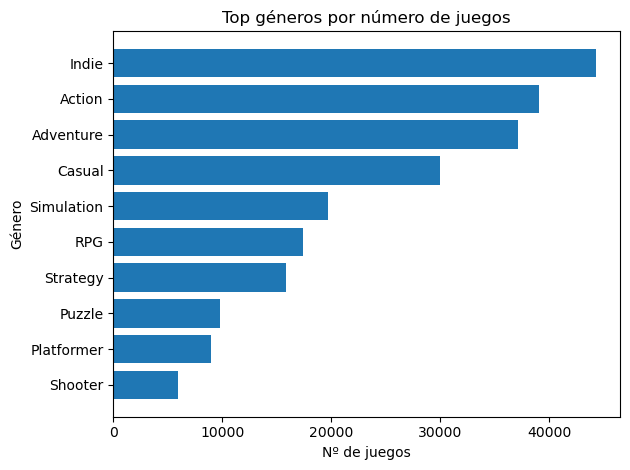

,label,value
0,Indie,44290
1,Action,39109
2,Adventure,37187
3,Casual,29967
4,Simulation,19709
5,RPG,17370
6,Strategy,15855
7,Puzzle,9823
8,Platformer,8925
9,Shooter,5899


In [23]:
# Prueba 1:

ask_visual("Top 10 géneros por número de juegos", limit=10)

 PRUEBA DE VISUALIZACIONES CON HUGGING FACE

────────────────────────────────────────────────────────────────────────────────
Pregunta 1/11: ¿Cuáles son los géneros más populares?
────────────────────────────────────────────────────────────────────────────────
Detectado: top_genres
Similitud: 61.9%
Gráfico: Top géneros por número de juegos


C:\Users\crisr\AppData\Local\Temp\ipykernel_13236\2215600779.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conn, params=params)


Intent: top_genres
Top géneros por número de juegos
        label  value
0       Indie  44290
1      Action  39109
2   Adventure  37187
3      Casual  29967
4  Simulation  19709
5         RPG  17370
6    Strategy  15855
7      Puzzle   9823
8  Platformer   8925
9     Shooter   5899


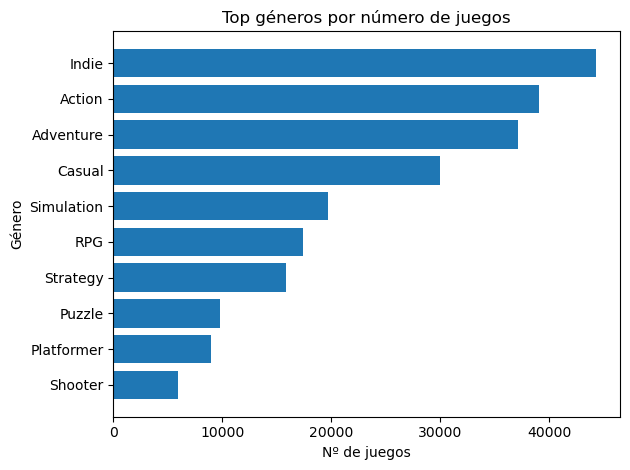



────────────────────────────────────────────────────────────────────────────────
Pregunta 2/11: Muéstrame las plataformas con más juegos
────────────────────────────────────────────────────────────────────────────────
Detectado: top_genres
Similitud: 46.7%
Gráfico: Top géneros por número de juegos


C:\Users\crisr\AppData\Local\Temp\ipykernel_13236\2215600779.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conn, params=params)


Intent: top_genres
Top géneros por número de juegos
        label  value
0       Indie  44290
1      Action  39109
2   Adventure  37187
3      Casual  29967
4  Simulation  19709
5         RPG  17370
6    Strategy  15855
7      Puzzle   9823
8  Platformer   8925
9     Shooter   5899


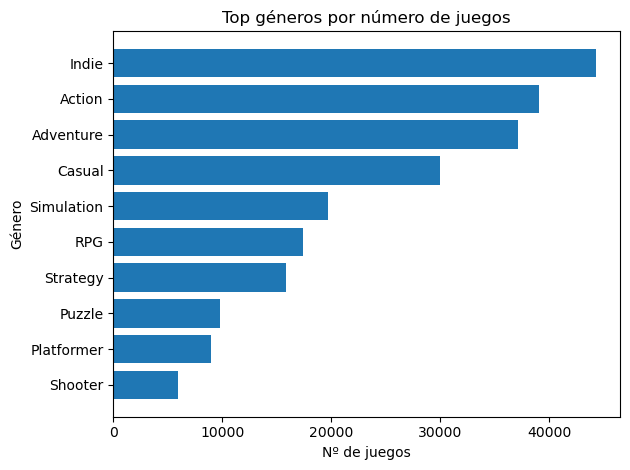



────────────────────────────────────────────────────────────────────────────────
Pregunta 3/11: Distribución por clasificación de edad
────────────────────────────────────────────────────────────────────────────────
Detectado: esrb_distribution
Similitud: 50.4%
Gráfico: Distribución por ESRB


C:\Users\crisr\AppData\Local\Temp\ipykernel_13236\2215600779.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conn, params=params)


Intent: esrb_distribution
Distribución por ESRB
            label   value
0         Unknown  123661
1    Everyone 10+    6293
2            Teen    3346
3          Mature    1549
4        Everyone    1416
5     Adults Only     862
6  Rating Pending      52


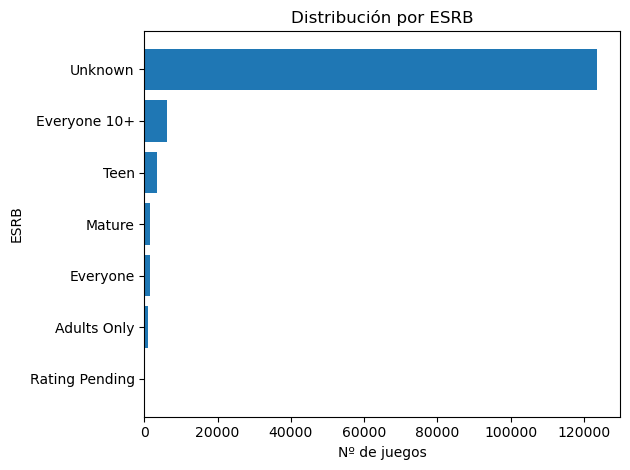



────────────────────────────────────────────────────────────────────────────────
Pregunta 4/11: Evolución del rating a lo largo del tiempo
────────────────────────────────────────────────────────────────────────────────
Detectado: avg_rating_by_release_month
Similitud: 44.8%
Gráfico: Rating medio por mes de publicación


C:\Users\crisr\AppData\Local\Temp\ipykernel_13236\2215600779.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conn, params=params)


Intent: avg_rating_by_release_month
Rating medio por mes de publicación
     label  value
0  2016-01  0.210
1  2016-02  0.286
2  2016-03  0.267
3  2016-04  0.302
4  2016-05  0.229
5  2016-06  0.269
6  2016-07  0.219
7  2016-08  0.280
8  2016-09  0.307
9  2016-10  0.363


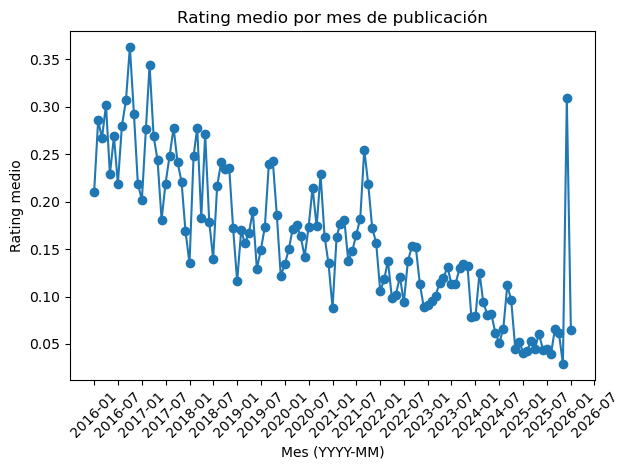



────────────────────────────────────────────────────────────────────────────────
Pregunta 5/11: top platforms
────────────────────────────────────────────────────────────────────────────────
Detectado: top_platforms
Similitud: 38.5%
Gráfico: Top plataformas por número de juegos


C:\Users\crisr\AppData\Local\Temp\ipykernel_13236\2215600779.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conn, params=params)


Intent: top_platforms
Top plataformas por número de juegos
             label   value
0               PC  105822
1            macOS   21144
2              Web   20661
3            Linux   14933
4              iOS   11595
5          Android    6622
6    PlayStation 4    5234
7  Nintendo Switch    4291
8         Xbox One    4076
9    PlayStation 5    1176


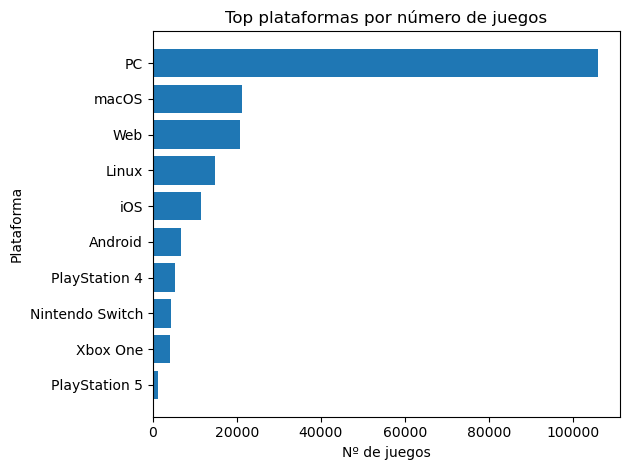



────────────────────────────────────────────────────────────────────────────────
Pregunta 6/11: games playing now
────────────────────────────────────────────────────────────────────────────────
Detectado: top_platforms
Similitud: 26.5%
Gráfico: Top plataformas por número de juegos


C:\Users\crisr\AppData\Local\Temp\ipykernel_13236\2215600779.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conn, params=params)


Intent: top_platforms
Top plataformas por número de juegos
             label   value
0               PC  105822
1            macOS   21144
2              Web   20661
3            Linux   14933
4              iOS   11595
5          Android    6622
6    PlayStation 4    5234
7  Nintendo Switch    4291
8         Xbox One    4076
9    PlayStation 5    1176


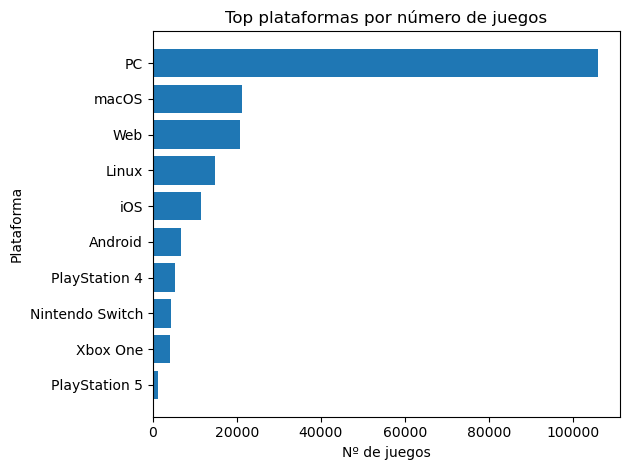



────────────────────────────────────────────────────────────────────────────────
Pregunta 7/11: tiendas digitales
────────────────────────────────────────────────────────────────────────────────
Detectado: top_stores
Similitud: 59.6%
Gráfico: Top stores por número de juegos


C:\Users\crisr\AppData\Local\Temp\ipykernel_13236\2215600779.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conn, params=params)


Intent: top_stores
Top stores por número de juegos
               label  value
0              Steam  63572
1            itch.io  61516
2          App Store  11434
3  PlayStation Store   4631
4                GOG   4055
5     Nintendo Store   3585
6         Xbox Store   3482
7        Google Play   2680
8         Epic Games   1191
9     Xbox 360 Store     38


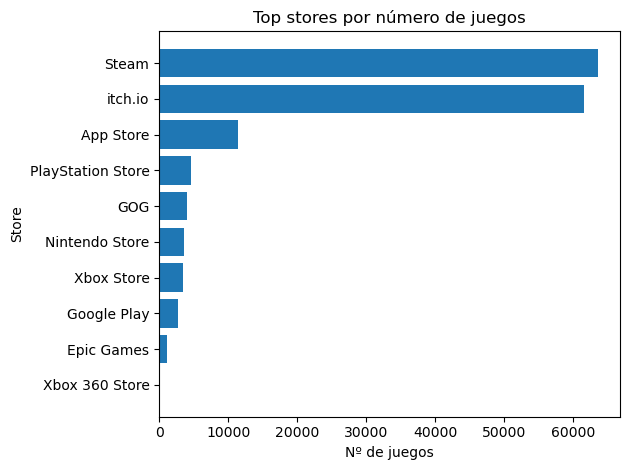



────────────────────────────────────────────────────────────────────────────────
Pregunta 8/11: tags más usados
────────────────────────────────────────────────────────────────────────────────
Detectado: top_genres
Similitud: 35.1%
Gráfico: Top géneros por número de juegos


C:\Users\crisr\AppData\Local\Temp\ipykernel_13236\2215600779.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conn, params=params)


Intent: top_genres
Top géneros por número de juegos
        label  value
0       Indie  44290
1      Action  39109
2   Adventure  37187
3      Casual  29967
4  Simulation  19709
5         RPG  17370
6    Strategy  15855
7      Puzzle   9823
8  Platformer   8925
9     Shooter   5899


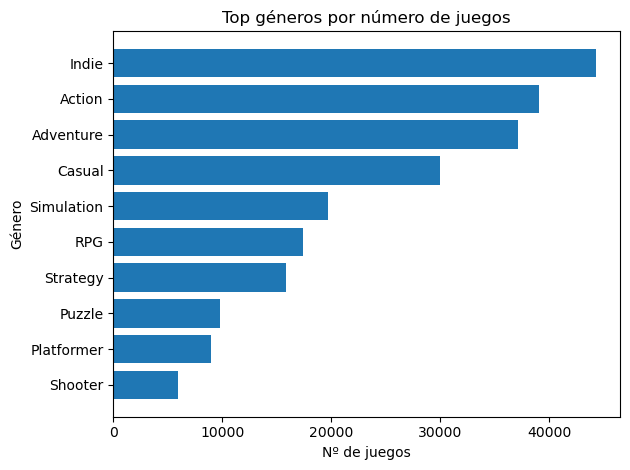



────────────────────────────────────────────────────────────────────────────────
Pregunta 9/11: juegos publicados cada mes
────────────────────────────────────────────────────────────────────────────────
Detectado: games_by_release_month
Similitud: 61.8%
Gráfico: Juegos publicados por mes


C:\Users\crisr\AppData\Local\Temp\ipykernel_13236\2215600779.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conn, params=params)


Intent: games_by_release_month
Juegos publicados por mes
     label  value
0  2016-01   1240
1  2016-02   1160
2  2016-03   1240
3  2016-04   1200
4  2016-05   1240
5  2016-06   1200
6  2016-07   1240
7  2016-08   1240
8  2016-09   1200
9  2016-10   1240


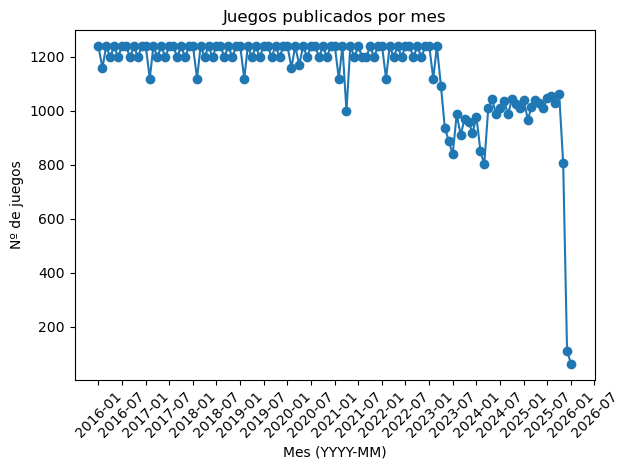



────────────────────────────────────────────────────────────────────────────────
Pregunta 10/11: muéstrame estadísticas de juegos
────────────────────────────────────────────────────────────────────────────────
Detectado: top_genres
Similitud: 42.3%
Gráfico: Top géneros por número de juegos


C:\Users\crisr\AppData\Local\Temp\ipykernel_13236\2215600779.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conn, params=params)


Intent: top_genres
Top géneros por número de juegos
        label  value
0       Indie  44290
1      Action  39109
2   Adventure  37187
3      Casual  29967
4  Simulation  19709
5         RPG  17370
6    Strategy  15855
7      Puzzle   9823
8  Platformer   8925
9     Shooter   5899


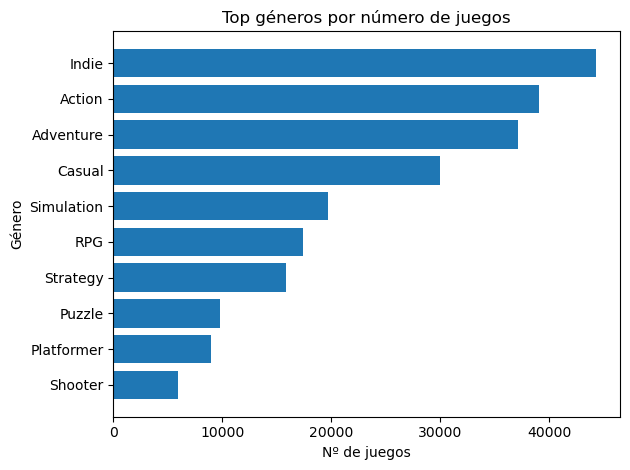



────────────────────────────────────────────────────────────────────────────────
Pregunta 11/11: algo completamente random
────────────────────────────────────────────────────────────────────────────────
Detectado: esrb_distribution
Similitud: 25.9%
Gráfico: Distribución por ESRB


C:\Users\crisr\AppData\Local\Temp\ipykernel_13236\2215600779.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conn, params=params)


Intent: esrb_distribution
Distribución por ESRB
            label   value
0         Unknown  123661
1    Everyone 10+    6293
2            Teen    3346
3          Mature    1549
4        Everyone    1416
5     Adults Only     862
6  Rating Pending      52


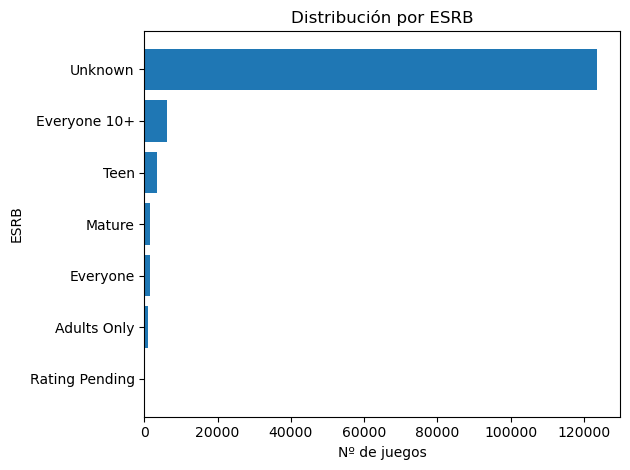

In [68]:
print("=" * 80)
print(" PRUEBA DE VISUALIZACIONES CON HUGGING FACE")
print("=" * 80)

test_questions = [
    # Preguntas claras
    "¿Cuáles son los géneros más populares?",
    "Muéstrame las plataformas con más juegos",
    "Distribución por clasificación de edad",
    "Evolución del rating a lo largo del tiempo",
    
    # Preguntas en inglés
    "top platforms",
    "games playing now",
    
    # Preguntas variadas
    "tiendas digitales",
    "tags más usados",
    "juegos publicados cada mes",
    
    # Pregunta ambigua
    "muéstrame estadísticas de juegos",
   
    # Sin match claro
    "algo completamente random",
] 

for i, question in enumerate(test_questions, 1):
    print(f"\n{'─' * 80}")
    print(f"Pregunta {i}/{len(test_questions)}: {question}")
    print('─' * 80)
    
    df = ask_visual(question, limit=10, debug = True)
    print()

# B) Resolver ask-visual con modelos Text-to-SQL dinámico:

Pregunta → Generar SQL dinámicamente → Ejecutar → Gráfico

Ventajas:  
- Mucho más flexible
- Responde preguntas no predefinidas

Desventajas:  
- Implementación más compleja
- Riesgo de seguridad SQL injection
- Requiere modelos grandes o API
- Más lento

**LIMITACIÓN**: Buscamos coste mínimo. La mejor opción es **Gemini API 2.5 flash** (coste cero hasta 10.000 peticiones), , que se aloja en remoto ocupando 0 MB en el servidor EC2 y da unos resultados aceptables. Nos permite crear la instancia más económica en EC2 que es t3.small ($15/mes).

Costo total: $15/mes (solo EC2)
Complejidad: Baja
Resultado: Text-to-SQL funcional sin GPU

Otras opciones valoradas han sido:  
- Uso de Modelo de Hugging Face con GPU en notebook de KAGGLE (coste cero en las pruebas) requiere abrir una instancia mínima de t3.large con un coste de ``$60/mes`` en producción.  
- Uso de Claude API requiere un coste de $15-20/mes y la instancia de EC2 tendría que ser t3.small (RAM necesaria: 100MB))

In [ ]:
#La estrategia escogida es híbrida para optimizar los costes: 
'''
┌─────────────────────────────────────────────────────────┐
│ EC2 t3.small ($15/mes)                                 │
│                                                         │
│  ┌───────────────────────────────────────────────────┐ │
│  │ FastAPI                                           │ │
│  │                                                   │ │
│  │  /ask-visual (clasificación)                     │ │
│  │  ├── VISUALS (catálogo SQL) ← 80% queries       │ │
│  │  │   Peso: 0 MB                                  │ │
│  │  │   Costo: $0                                   │ │
│  │  │   Velocidad: <100 ms                          │ │
│  │  │                                               │ │
│  │  └── Gemini API ← 20% queries fuera catálogo    │ │
│  │      Peso: 0 MB                                  │ │
│  │      Costo: $0 (plan gratis)                     │ │
│  │      Velocidad: 1-2 seg                          │ │
│  └───────────────────────────────────────────────────┘ │
│                                                         │
│  RAM usada: ~500 MB (FastAPI + librerías)              │
│  Disco usado: ~2 GB (OS + código)                      │
└─────────────────────────────────────────────────────────┘

                         ↓ Queries SQL

                        
┌─────────────────────────────────────────────────────────┐
│ RDS PostgreSQL                                          │
│ db.t3.micro ($15/mes)                                  │
└─────────────────────────────────────────────────────────┘

COSTO TOTAL: $30/mes
'''

In [43]:

# === Imports y configuración inicial ===


import google.generativeai as genai
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from typing import Optional, Tuple
import json

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

print(" Imports completados")

 Imports completados


In [44]:
# === Configuración de Gemini API ===

GEMINI_API_KEY = "****************" 

# Configurar Gemini
genai.configure(api_key=GEMINI_API_KEY)

# Usar modelo gratuito
model = genai.GenerativeModel('models/gemini-2.5-flash')

print(" Gemini API configurado correctamente")
print(f"Modelo: Gemini 2.5 Flash (GRATIS - MÁS RECIENTE)")

 Gemini API configurado correctamente
Modelo: Gemini 2.5 Flash (GRATIS - MÁS RECIENTE)


In [47]:
# === Conectar con la instancia de RDS ===

from utils.aws_secrets import get_rds_credentials

SECRET_NAME = os.getenv("DB_SECRET_NAME", "Postgre") 
DB_SCHEMA = os.getenv("DB_SCHEMA", "rawg")

def get_connection():
    creds = get_rds_credentials(SECRET_NAME) 
    return psycopg2.connect(
        host=creds["host"],
        port=int(creds["port"]),
        dbname=creds["dbname"],
        user=creds["username"],
        password=creds["password"],
        sslmode="require",
        connect_timeout=10,
        application_name="rawg-notebook",
    )
print("Configuración de BD lista")

Configuración de BD lista


In [48]:

# === Funciones para interactuar con PostgreSQL ===

def query_to_dataframe(sql: str) -> pd.DataFrame:
    """
    Ejecuta SQL y retorna DataFrame
    
    Args:
        sql: Query SQL a ejecutar
        
    Returns:
        DataFrame con resultados
    """
    conn = get_connection()
    try:
        df = pd.read_sql_query(sql, conn)
        print(f"Query ejecutada. Filas obtenidas: {len(df)}")
        return df
    except Exception as e:
        print(f"Error ejecutando query: {e}")
        raise
    finally:
        conn.close()


def validate_sql_security(sql: str) -> bool:
    """
    Valida que el SQL sea seguro (solo SELECT)
    
    Args:
        sql: Query a validar
        
    Returns:
        True si es seguro, False si no
    """
    sql_lower = sql.lower().strip()
    
    # Debe empezar con SELECT
    if not sql_lower.startswith('select'):
        print(f"SQL no empieza con SELECT")
        return False
    
    # No debe contener comandos peligrosos
    forbidden = ['drop', 'delete', 'update', 'insert', 'alter', 'truncate', 'create']
    
    for word in forbidden:
        if word in sql_lower:
            print(f"SQL contiene palabra prohibida: {word}")
            return False
    
    return True


# Test de conexión
try:
    conn = get_connection()
    print("Conexión a RDS exitosa")
    conn.close()
except Exception as e:
    print(f"Error: {e}")

Conexión a RDS exitosa


In [64]:

# === Esquema de base de datos en RDS ===


DATABASE_SCHEMA = f"""
Base de datos PostgreSQL - Schema: {DB_SCHEMA}

════════════════════════════════════════════════════════════════════════════
TABLAS DE DIMENSIONES / CATÁLOGOS
════════════════════════════════════════════════════════════════════════════

1. {DB_SCHEMA}.esrb_ratings
   - esrb_id (INT, PK)
   - esrb_name (VARCHAR 100)

2. {DB_SCHEMA}.platforms
   - platform_id (INT, PK)
   - platform_name (VARCHAR 200)

3. {DB_SCHEMA}.genres
   - genre_id (INT, PK)
   - genre_name (VARCHAR 100)
   - genre_games_count (BIGINT)

4. {DB_SCHEMA}.stores
   - store_id (INT, PK)
   - store_name (VARCHAR 200)

5. {DB_SCHEMA}.tags
   - tag_id (BIGINT, PK)
   - tag_name (VARCHAR 200)
   - tag_language (VARCHAR 50)
   - tag_games_count (BIGINT)

════════════════════════════════════════════════════════════════════════════
TABLA PRINCIPAL: {DB_SCHEMA}.games
════════════════════════════════════════════════════════════════════════════

Columnas:
- game_id (BIGINT, PK) - ID único del juego
- game_name (VARCHAR 500) - Nombre del juego
- tba (BOOLEAN) - To Be Announced
- released_ym (CHAR 7) - Fecha lanzamiento formato "YYYY-MM"
- updated_ym (CHAR 7) - Fecha actualización formato "YYYY-MM"
- game_rating (NUMERIC 4,2) - Rating promedio (0.00 - 5.00)
- ratings_count (BIGINT) - Cantidad de ratings
- game_added (BIGINT) - Veces agregado a colecciones
- playtime (INTEGER) - Tiempo promedio de juego en horas
- suggestions_count (BIGINT) - Sugerencias recibidas
- esrb_id (INT, FK) - ID clasificación ESRB
- created_at (TIMESTAMP) - Fecha creación registro

════════════════════════════════════════════════════════════════════════════
TABLA: {DB_SCHEMA}.games_status
════════════════════════════════════════════════════════════════════════════

Columnas:
- game_id (BIGINT, PK/FK)
- yet (BIGINT) - Aún no jugado
- owned (BIGINT) - Propietarios
- beaten (BIGINT) - Completado
- toplay (BIGINT) - Para jugar
- dropped (BIGINT) - Abandonado
- playing (BIGINT) - Jugando actualmente

════════════════════════════════════════════════════════════════════════════
TABLA: {DB_SCHEMA}.ratings_distribution
════════════════════════════════════════════════════════════════════════════

Columnas:
- game_id (BIGINT, PK/FK)
- ratingd_id (INT, PK)
- ratingd_title (VARCHAR 50)
- ratingd_count (BIGINT)
- ratingd_percent (NUMERIC 6,2)

════════════════════════════════════════════════════════════════════════════
TABLAS DE RELACIÓN N:M
════════════════════════════════════════════════════════════════════════════

6. {DB_SCHEMA}.game_platforms
   - game_id (BIGINT, PK/FK)
   - platform_id (INT, PK/FK)
   - released_at (VARCHAR 10)

7. {DB_SCHEMA}.game_genres
   - game_id (BIGINT, PK/FK)
   - genre_id (INT, PK/FK)

8. {DB_SCHEMA}.game_stores
   - game_id (BIGINT, PK/FK)
   - store_id (INT, PK/FK)

9. {DB_SCHEMA}.game_tags
   - game_id (BIGINT, PK/FK)
   - tag_id (BIGINT, PK/FK)
"""

print("Esquema de RDS cargado correctamente")
print(DATABASE_SCHEMA)

Esquema de RDS cargado correctamente

Base de datos PostgreSQL - Schema: rawg

════════════════════════════════════════════════════════════════════════════
TABLAS DE DIMENSIONES / CATÁLOGOS
════════════════════════════════════════════════════════════════════════════

1. rawg.esrb_ratings
   - esrb_id (INT, PK)
   - esrb_name (VARCHAR 100)

2. rawg.platforms
   - platform_id (INT, PK)
   - platform_name (VARCHAR 200)

3. rawg.genres
   - genre_id (INT, PK)
   - genre_name (VARCHAR 100)
   - genre_games_count (BIGINT)

4. rawg.stores
   - store_id (INT, PK)
   - store_name (VARCHAR 200)

5. rawg.tags
   - tag_id (BIGINT, PK)
   - tag_name (VARCHAR 200)
   - tag_language (VARCHAR 50)
   - tag_games_count (BIGINT)

════════════════════════════════════════════════════════════════════════════
TABLA PRINCIPAL: rawg.games
════════════════════════════════════════════════════════════════════════════

Columnas:
- game_id (BIGINT, PK) - ID único del juego
- game_name (VARCHAR 500) - Nombre del jue

In [65]:

# === Generar SQL para visualizaciones ===


def generate_sql_for_visual(question: str) -> Optional[str]:
    """Genera SQL para visualización usando esquema REAL de RDS"""
    
    prompt = f"""Eres experto en SQL PostgreSQL para visualización de datos.

ESQUEMA DE BASE DE DATOS:
{DATABASE_SCHEMA}

PREGUNTA DEL USUARIO:
{question}

REQUISITOS ESTRICTOS:
1. SOLO SQL PostgreSQL, sin markdown ni explicaciones
2. Retornar columnas "label" (TEXT) y "value" (NUMERIC/BIGINT)
3. Usar schema "{DB_SCHEMA}"
4. NOMBRES CORRECTOS DE CAMPOS:
   - Rating: "game_rating" (NO "rating")
   - Agregado: "game_added" (NO "added")
   - Fecha: "released_ym" (NO "released")
5. Para extraer año: SUBSTRING(released_ym, 1, 4)::integer
6. Para series temporales: released_ym AS label
7. Rankings: ORDER BY value DESC LIMIT 10
8. Series: ORDER BY label
9. NO usar DROP, DELETE, UPDATE, INSERT
10. Conteos: ::bigint
11. Promedios: ROUND(..., 2)

EJEMPLOS CORRECTOS:

-- Top géneros
SELECT g.genre_name AS label, COUNT(*)::bigint AS value
FROM {DB_SCHEMA}.game_genres gg
JOIN {DB_SCHEMA}.genres g ON g.genre_id = gg.genre_id
GROUP BY g.genre_name
ORDER BY value DESC LIMIT 10;

-- Juegos por año desde 2015
SELECT SUBSTRING(released_ym, 1, 4) AS label, 
       COUNT(*)::bigint AS value
FROM {DB_SCHEMA}.games
WHERE released_ym IS NOT NULL 
  AND SUBSTRING(released_ym, 1, 4)::integer >= 2015
GROUP BY SUBSTRING(released_ym, 1, 4)
ORDER BY label;

-- Rating promedio por año
SELECT SUBSTRING(released_ym, 1, 4) AS label, 
       ROUND(AVG(game_rating)::numeric, 2) AS value
FROM {DB_SCHEMA}.games
WHERE released_ym IS NOT NULL AND game_rating IS NOT NULL
GROUP BY SUBSTRING(released_ym, 1, 4)
ORDER BY label;

-- Juegos por mes (serie temporal)
SELECT released_ym AS label, 
       COUNT(*)::bigint AS value
FROM {DB_SCHEMA}.games
WHERE released_ym IS NOT NULL
GROUP BY released_ym
ORDER BY label;

-- Top plataformas
SELECT p.platform_name AS label, COUNT(*)::bigint AS value
FROM {DB_SCHEMA}.game_platforms gp
JOIN {DB_SCHEMA}.platforms p ON p.platform_id = gp.platform_id
GROUP BY p.platform_name
ORDER BY value DESC LIMIT 10;

-- Top stores
SELECT s.store_name AS label, COUNT(*)::bigint AS value
FROM {DB_SCHEMA}.game_stores gs
JOIN {DB_SCHEMA}.stores s ON s.store_id = gs.store_id
GROUP BY s.store_name
ORDER BY value DESC LIMIT 10;

-- Distribución ESRB
SELECT COALESCE(e.esrb_name, 'Sin clasificar') AS label, 
       COUNT(*)::bigint AS value
FROM {DB_SCHEMA}.games g
LEFT JOIN {DB_SCHEMA}.esrb_ratings e ON g.esrb_id = e.esrb_id
GROUP BY e.esrb_name
ORDER BY value DESC;

-- Juegos jugando actualmente (top 10)
SELECT g.game_name AS label, s.playing::bigint AS value
FROM {DB_SCHEMA}.games_status s
JOIN {DB_SCHEMA}.games g ON g.game_id = s.game_id
WHERE s.playing > 0
ORDER BY s.playing DESC LIMIT 10;

Genera SOLO el SQL para la pregunta:"""

    try:
        response = model.generate_content(prompt)
        sql = response.text.strip().replace('```sql', '').replace('```', '').strip()
        
        if not validate_sql_security(sql):
            print("SQL no pasó validación de seguridad")
            return None
        
        print(f"SQL generado correctamente")
        print(f"SQL:\n{sql}\n")
        
        return sql
        
    except Exception as e:
        print(f"Error generando SQL: {e}")
        return None

In [67]:

# === Generar SQL para respuestas textuales ===


def generate_sql_for_text(question: str) -> Optional[str]:
    """
    Genera SQL para respuesta textual usando esquema REAL de RDS
    
    La query puede retornar múltiples columnas según la pregunta
    
    Args:
        question: Pregunta del usuario
        
    Returns:
        SQL query generada o None si falla
    """
    
    prompt = f"""Eres experto en SQL PostgreSQL para análisis de datos de videojuegos.

ESQUEMA DE BASE DE DATOS:
{DATABASE_SCHEMA}

PREGUNTA DEL USUARIO:
{question}

REQUISITOS ESTRICTOS:
1. SOLO SQL PostgreSQL, sin markdown ni explicaciones
2. Retornar columnas con nombres descriptivos según la pregunta
3. Usar schema "{DB_SCHEMA}"
4. NOMBRES CORRECTOS DE CAMPOS:
   - Rating: "game_rating" (NO "rating")
   - Agregado: "game_added" (NO "added")
   - Fecha: "released_ym" (NO "released")
   - Nombre juego: "game_name" (NO "name")
5. LIMIT máximo 20 resultados
6. NO usar DROP, DELETE, UPDATE, INSERT
7. Conteos: ::bigint
8. Promedios: ROUND(..., 2)
9. Ordenar lógicamente según la pregunta

EJEMPLOS CORRECTOS:

-- ¿Cuál es el juego mejor valorado?
SELECT game_name AS juego, 
       game_rating AS puntuacion,
       ratings_count AS num_votos
FROM {DB_SCHEMA}.games
WHERE game_rating IS NOT NULL
ORDER BY game_rating DESC, ratings_count DESC
LIMIT 1;

-- ¿Cuántos juegos hay en total?
SELECT COUNT(*)::bigint AS total_juegos
FROM {DB_SCHEMA}.games;

-- ¿Cuál es el rating promedio?
SELECT ROUND(AVG(game_rating)::numeric, 2) AS rating_promedio,
       COUNT(*)::bigint AS juegos_con_rating
FROM {DB_SCHEMA}.games
WHERE game_rating IS NOT NULL;

-- ¿Qué género tiene mejor rating promedio?
SELECT g.genre_name AS genero, 
       ROUND(AVG(ga.game_rating)::numeric, 2) AS rating_promedio,
       COUNT(*)::bigint AS num_juegos
FROM {DB_SCHEMA}.game_genres gg
JOIN {DB_SCHEMA}.genres g ON g.genre_id = gg.genre_id
JOIN {DB_SCHEMA}.games ga ON ga.game_id = gg.game_id
WHERE ga.game_rating IS NOT NULL
GROUP BY g.genre_name
HAVING COUNT(*) >= 10
ORDER BY rating_promedio DESC
LIMIT 1;

-- ¿Cuáles son los 5 juegos con más tiempo de juego?
SELECT game_name AS juego,
       playtime AS horas_promedio,
       game_rating AS puntuacion
FROM {DB_SCHEMA}.games
WHERE playtime IS NOT NULL AND playtime > 0
ORDER BY playtime DESC
LIMIT 5;

-- ¿Qué juegos están jugando más personas ahora?
SELECT g.game_name AS juego,
       s.playing AS jugadores_activos,
       g.game_rating AS puntuacion
FROM {DB_SCHEMA}.games_status s
JOIN {DB_SCHEMA}.games g ON g.game_id = s.game_id
WHERE s.playing > 0
ORDER BY s.playing DESC
LIMIT 5;

-- ¿Cuántos juegos se lanzaron en 2024?
SELECT COUNT(*)::bigint AS juegos_2024
FROM {DB_SCHEMA}.games
WHERE released_ym IS NOT NULL 
  AND SUBSTRING(released_ym, 1, 4) = '2024';

-- ¿Cuál es la plataforma con más juegos?
SELECT p.platform_name AS plataforma,
       COUNT(*)::bigint AS total_juegos
FROM {DB_SCHEMA}.game_platforms gp
JOIN {DB_SCHEMA}.platforms p ON p.platform_id = gp.platform_id
GROUP BY p.platform_name
ORDER BY total_juegos DESC
LIMIT 1;

-- ¿Qué juegos tienen rating perfecto (5.0)?
SELECT game_name AS juego,
       game_rating AS puntuacion,
       ratings_count AS num_votos,
       released_ym AS lanzamiento
FROM {DB_SCHEMA}.games
WHERE game_rating = 5.0
ORDER BY ratings_count DESC
LIMIT 10;

-- ¿Cuál es el juego más agregado a colecciones?
SELECT game_name AS juego,
       game_added AS veces_agregado,
       game_rating AS puntuacion
FROM {DB_SCHEMA}.games
WHERE game_added IS NOT NULL
ORDER BY game_added DESC
LIMIT 1;

-- ¿Cuántos juegos hay por clasificación ESRB?
SELECT COALESCE(e.esrb_name, 'Sin clasificar') AS clasificacion,
       COUNT(*)::bigint AS total_juegos
FROM {DB_SCHEMA}.games g
LEFT JOIN {DB_SCHEMA}.esrb_ratings e ON g.esrb_id = e.esrb_id
GROUP BY e.esrb_name
ORDER BY total_juegos DESC;

-- ¿Qué tags son más populares?
SELECT t.tag_name AS tag,
       COUNT(*)::bigint AS num_juegos,
       ROUND(AVG(g.game_rating)::numeric, 2) AS rating_promedio
FROM {DB_SCHEMA}.game_tags gt
JOIN {DB_SCHEMA}.tags t ON t.tag_id = gt.tag_id
JOIN {DB_SCHEMA}.games g ON g.game_id = gt.game_id
WHERE g.game_rating IS NOT NULL
GROUP BY t.tag_name
ORDER BY num_juegos DESC
LIMIT 10;

-- ¿Cuántos juegos están marcados como "para jugar"?
SELECT COUNT(*)::bigint AS juegos_pendientes,
       SUM(s.toplay)::bigint AS total_usuarios
FROM {DB_SCHEMA}.games_status s
WHERE s.toplay > 0;

Genera SOLO el SQL para la pregunta:"""

    try:
        response = model.generate_content(prompt)
        sql = response.text.strip().replace('```sql', '').replace('```', '').strip()
        
        # Validar seguridad
        if not validate_sql_security(sql):
            print("SQL no pasó validación de seguridad")
            return None
        
        print(f"SQL generado correctamente")
        print(f"SQL:\n{sql}\n")
        
        return sql
        
    except Exception as e:
        print(f"Error generando SQL: {e}")
        return None

In [68]:

# === Generar respuesta en lenguaje natural ===


def generate_text_response(question: str, df: pd.DataFrame) -> str:
    """
    Genera respuesta en lenguaje natural basada en los datos
    
    Args:
        question: Pregunta original del usuario
        df: DataFrame con resultados de la query
        
    Returns:
        Respuesta en texto natural
    """
    
    # Convertir DataFrame a texto para el prompt
    data_summary = df.to_string(index=False, max_rows=20)
    
    prompt = f"""Eres un asistente de análisis de datos de videojuegos.

PREGUNTA DEL USUARIO:
{question}

DATOS OBTENIDOS:
{data_summary}

INSTRUCCIONES:
1. Responde la pregunta del usuario de forma clara y concisa
2. Usa los datos proporcionados para fundamentar tu respuesta
3. Si hay múltiples resultados, menciona los más relevantes (top 3-5)
4. Incluye números específicos cuando sea relevante
5. Usa un tono profesional pero amigable
6. Máximo 3-4 oraciones
7. NO inventes datos que no estén en la tabla

EJEMPLO DE RESPUESTA:
"El género más popular es Action con 5,234 juegos, seguido de Indie con 4,567 juegos y Adventure con 3,890 juegos. Estos tres géneros representan aproximadamente el 40% del total de juegos en la base de datos."

Genera tu respuesta:"""

    try:
        response = model.generate_content(prompt)
        answer = response.text.strip()
        
        print(f"Respuesta generada")
        return answer
        
    except Exception as e:
        print(f"Error generando respuesta: {e}")
        return f"Error al generar respuesta: {str(e)}"

In [69]:

# === Función ask_visual - Pregunta → SQL → Gráfico ===


def ask_visual(question: str, chart_type: str = "auto") -> Tuple[pd.DataFrame, str]:
    """
    Responde pregunta con visualización
    
    Args:
        question: Pregunta del usuario
        chart_type: "barh", "line", "auto" (detecta automático)
        
    Returns:
        (DataFrame, SQL generado)
    """
    
    print("=" * 80)
    print(f"ASK-VISUAL: {question}")
    print("=" * 80)
    
    # Paso 1: Generar SQL con Gemini
    sql = generate_sql_for_visual(question)
    
    if not sql:
        print(" No se pudo generar SQL")
        return None, None
    
    # Paso 2: Ejecutar SQL
    try:
        df = query_to_dataframe(sql)
    except Exception as e:
        print(f" Error ejecutando SQL: {e}")
        return None, sql
    
    # Paso 3: Validar formato
    if df.empty:
        print(" La query no retornó datos")
        return df, sql
    
    if not {"label", "value"}.issubset(df.columns):
        print(f" Columnas incorrectas. Esperadas: ['label', 'value'], Obtenidas: {list(df.columns)}")
        return df, sql
    
    # Paso 4: Detectar tipo de gráfico si es auto
    if chart_type == "auto":
        # Si label parece fecha → line, sino → barh
        try:
            pd.to_datetime(df['label'].iloc[0])
            chart_type = "line"
        except:
            chart_type = "barh"
    
    # Paso 5: Generar gráfico
    fig, ax = plt.subplots(figsize=(12, 6))
    
    if chart_type == "barh":
        # Ordenar y graficar barras horizontales
        df_sorted = df.sort_values("value", ascending=True)
        ax.barh(df_sorted["label"].astype(str), df_sorted["value"], color='steelblue')
        ax.set_xlabel("Valor", fontweight='bold')
        ax.set_ylabel("Categoría", fontweight='bold')
        
    elif chart_type == "line":
        # Gráfico de línea temporal
        df['label_dt'] = pd.to_datetime(df['label'])
        df_sorted = df.sort_values("label_dt")
        ax.plot(df_sorted["label_dt"], df_sorted["value"], marker='o', linewidth=2)
        ax.set_xlabel("Fecha", fontweight='bold')
        ax.set_ylabel("Valor", fontweight='bold')
        plt.xticks(rotation=45)
    
    ax.set_title(question, fontsize=14, fontweight='bold', pad=20)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Paso 6: Mostrar datos
    print(f"\nDatos obtenidos ({len(df)} filas):")
    print(df.head(10))
    
    return df, sql

In [70]:

# === Función ask_text - Pregunta → SQL → Respuesta Texto ===


def ask_text(question: str) -> Tuple[str, pd.DataFrame, str]:
    """
    Responde pregunta con texto natural
    
    Args:
        question: Pregunta del usuario
        
    Returns:
        (Respuesta texto, DataFrame, SQL generado)
    """
    
    print("=" * 80)
    print(f" ASK-TEXT: {question}")
    print("=" * 80)
    
    # Paso 1: Generar SQL con Gemini
    sql = generate_sql_for_text(question)
    
    if not sql:
        print("No se pudo generar SQL")
        return None, None, None
    
    # Paso 2: Ejecutar SQL
    try:
        df = query_to_dataframe(sql)
    except Exception as e:
        print(f"Error ejecutando SQL: {e}")
        return None, None, sql
    
    # Paso 3: Validar datos
    if df.empty:
        answer = "No se encontraron datos para responder tu pregunta."
        print(f"{answer}")
        return answer, df, sql
    
    # Paso 4: Generar respuesta textual con Gemini
    answer = generate_text_response(question, df)
    
    # Paso 5: Mostrar resultados
    print(f"\n RESPUESTA:")
    print(answer)
    
    print(f"\n Datos utilizados ({len(df)} filas):")
    print(df.head(10))
    
    return answer, df, sql

 PRUEBAS DE ASK-VISUAL


################################################################################
PRUEBA 1/5
################################################################################

ASK-VISUAL: Top 10 géneros con más juegos
SQL generado correctamente
SQL:
SELECT g.genre_name AS label, COUNT(*)::bigint AS value
FROM rawg.game_genres gg
JOIN rawg.genres g ON g.genre_id = gg.genre_id
GROUP BY g.genre_name
ORDER BY value DESC LIMIT 10;



C:\Users\crisr\AppData\Local\Temp\ipykernel_24872\1208585674.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


Query ejecutada. Filas obtenidas: 10


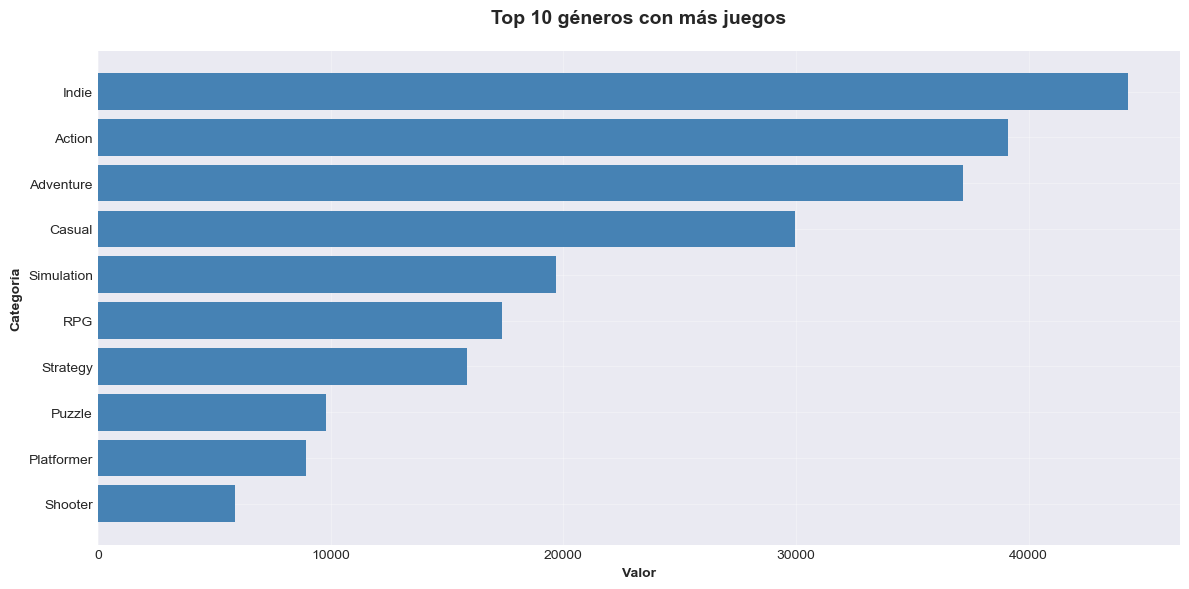


Datos obtenidos (10 filas):
        label  value
0       Indie  44290
1      Action  39109
2   Adventure  37187
3      Casual  29967
4  Simulation  19709
5         RPG  17370
6    Strategy  15855
7      Puzzle   9823
8  Platformer   8925
9     Shooter   5899
Prueba 1 completada



Presiona Enter para continuar... 



################################################################################
PRUEBA 2/5
################################################################################

ASK-VISUAL: Plataformas más populares
SQL generado correctamente
SQL:
SELECT p.platform_name AS label, COUNT(*)::bigint AS value
FROM rawg.game_platforms gp
JOIN rawg.platforms p ON p.platform_id = gp.platform_id
GROUP BY p.platform_name
ORDER BY value DESC LIMIT 10;



C:\Users\crisr\AppData\Local\Temp\ipykernel_24872\1208585674.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


Query ejecutada. Filas obtenidas: 10


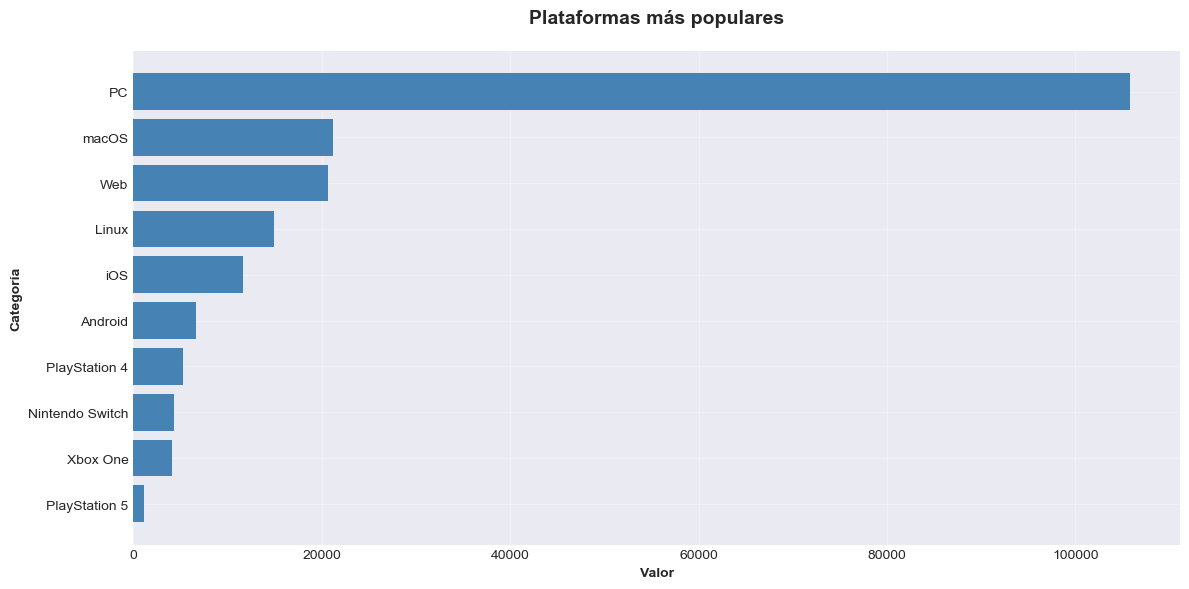


Datos obtenidos (10 filas):
             label   value
0               PC  105822
1            macOS   21144
2              Web   20661
3            Linux   14933
4              iOS   11595
5          Android    6622
6    PlayStation 4    5234
7  Nintendo Switch    4291
8         Xbox One    4076
9    PlayStation 5    1176
Prueba 2 completada



Presiona Enter para continuar... 



################################################################################
PRUEBA 3/5
################################################################################

ASK-VISUAL: Evolución del número de juegos lanzados por año desde 2015
SQL generado correctamente
SQL:
SELECT SUBSTRING(released_ym, 1, 4) AS label,
       COUNT(*)::bigint AS value
FROM rawg.games
WHERE released_ym IS NOT NULL
  AND SUBSTRING(released_ym, 1, 4)::integer >= 2015
GROUP BY SUBSTRING(released_ym, 1, 4)
ORDER BY label;



C:\Users\crisr\AppData\Local\Temp\ipykernel_24872\1208585674.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


Query ejecutada. Filas obtenidas: 11


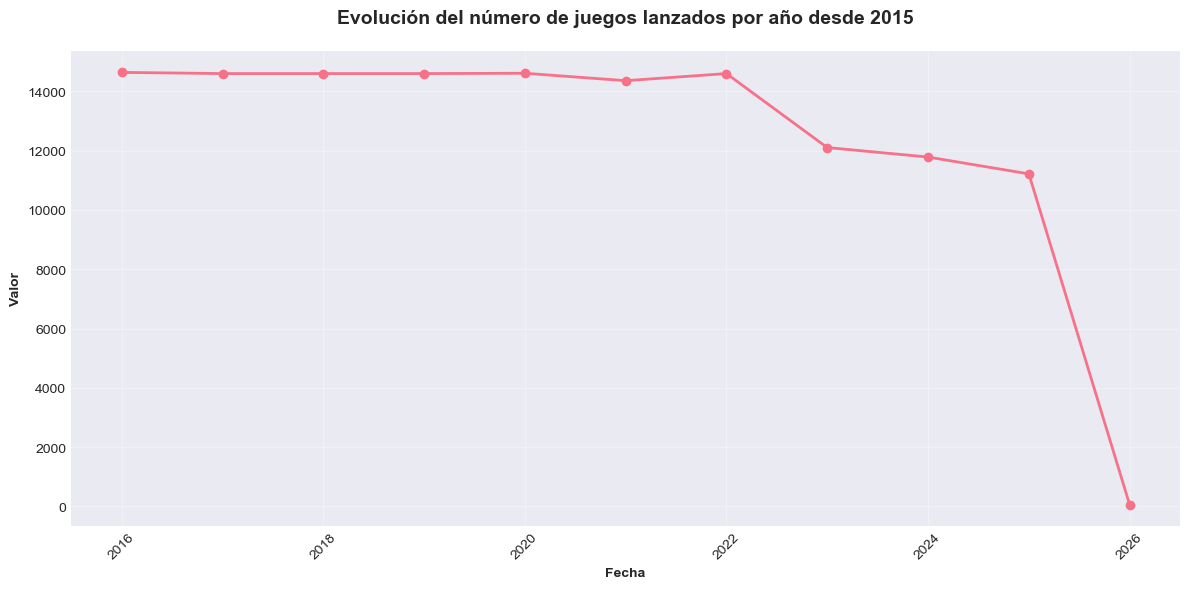


Datos obtenidos (11 filas):
  label  value   label_dt
0  2016  14640 2016-01-01
1  2017  14600 2017-01-01
2  2018  14600 2018-01-01
3  2019  14600 2019-01-01
4  2020  14611 2020-01-01
5  2021  14360 2021-01-01
6  2022  14600 2022-01-01
7  2023  12105 2023-01-01
8  2024  11785 2024-01-01
9  2025  11216 2025-01-01
Prueba 3 completada



Presiona Enter para continuar... 



################################################################################
PRUEBA 4/5
################################################################################

ASK-VISUAL: Top 5 stores con más juegos
SQL generado correctamente
SQL:
SELECT s.store_name AS label, COUNT(*)::bigint AS value
FROM rawg.game_stores gs
JOIN rawg.stores s ON s.store_id = gs.store_id
GROUP BY s.store_name
ORDER BY value DESC LIMIT 5;



C:\Users\crisr\AppData\Local\Temp\ipykernel_24872\1208585674.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


Query ejecutada. Filas obtenidas: 5


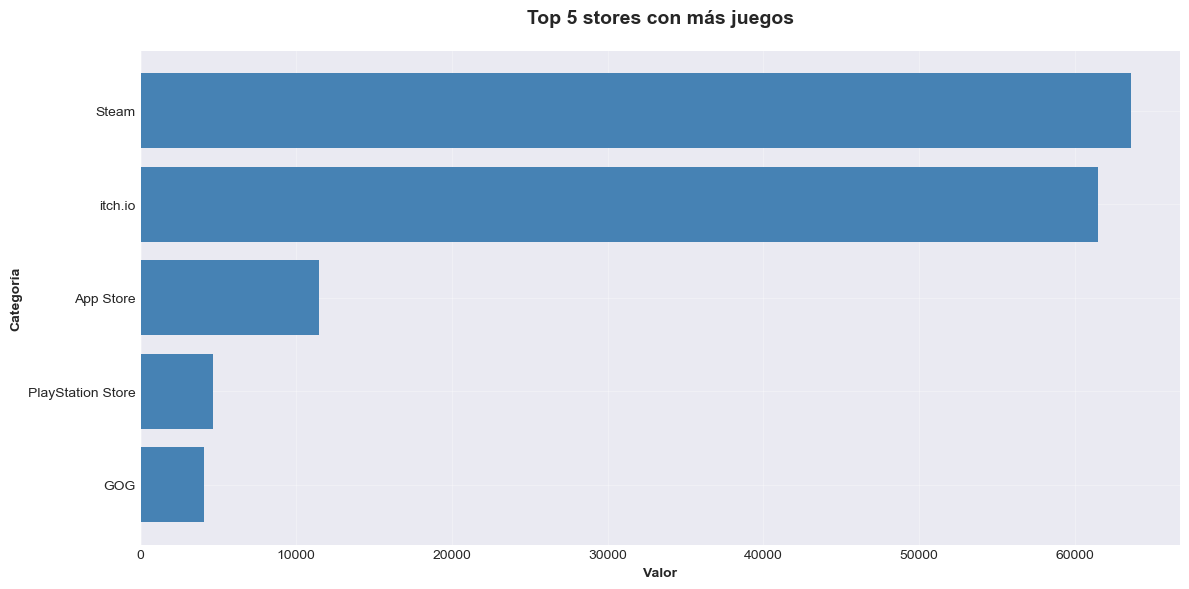


Datos obtenidos (5 filas):
               label  value
0              Steam  63572
1            itch.io  61516
2          App Store  11434
3  PlayStation Store   4631
4                GOG   4055
Prueba 4 completada



Presiona Enter para continuar... 



################################################################################
PRUEBA 5/5
################################################################################

ASK-VISUAL: Distribución de juegos por clasificación ESRB
SQL generado correctamente
SQL:
SELECT COALESCE(e.esrb_name, 'Sin clasificar') AS label,
       COUNT(*)::bigint AS value
FROM rawg.games g
LEFT JOIN rawg.esrb_ratings e ON g.esrb_id = e.esrb_id
GROUP BY e.esrb_name
ORDER BY value DESC;



C:\Users\crisr\AppData\Local\Temp\ipykernel_24872\1208585674.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


Query ejecutada. Filas obtenidas: 7


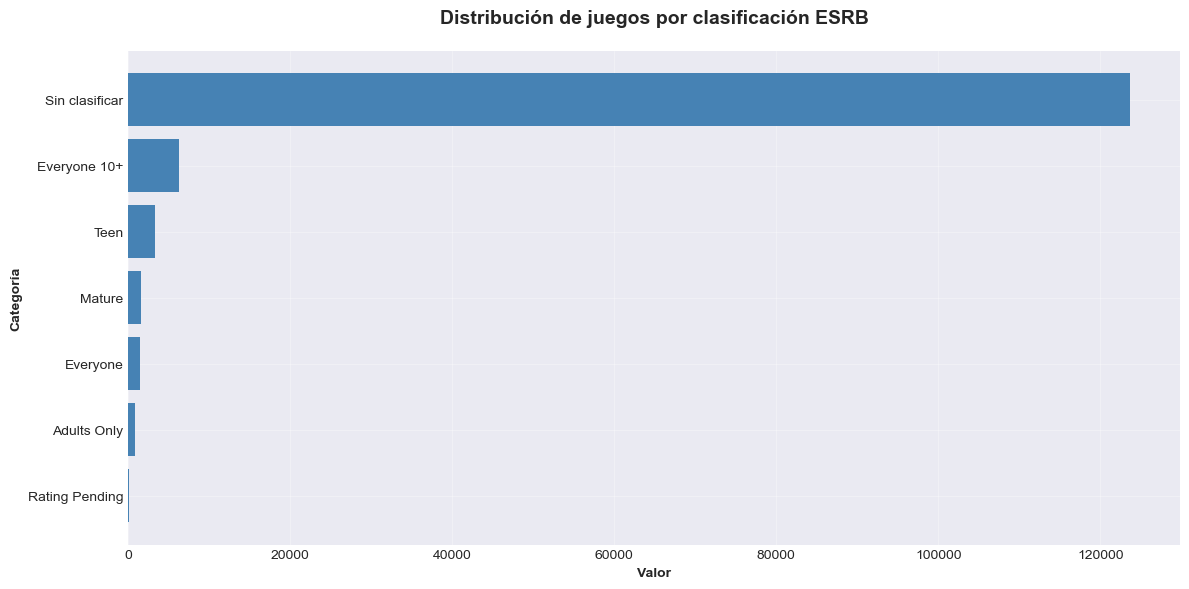


Datos obtenidos (7 filas):
            label   value
0  Sin clasificar  123661
1    Everyone 10+    6293
2            Teen    3346
3          Mature    1549
4        Everyone    1416
5     Adults Only     862
6  Rating Pending      52
Prueba 5 completada



Presiona Enter para continuar... 


In [71]:

# === Pruebas de ask_visual ===


test_visual_questions = [
    "Top 10 géneros con más juegos",
    "Plataformas más populares",
    "Evolución del número de juegos lanzados por año desde 2015",
    "Top 5 stores con más juegos",
    "Distribución de juegos por clasificación ESRB",
]

print(" PRUEBAS DE ASK-VISUAL\n")

for i, q in enumerate(test_visual_questions, 1):
    print(f"\n{'#' * 80}")
    print(f"PRUEBA {i}/{len(test_visual_questions)}")
    print(f"{'#' * 80}\n")
    
    df, sql = ask_visual(q)
    
    if df is not None:
        print(f"Prueba {i} completada\n")
    else:
        print(f"Prueba {i} falló\n")
    
    input("Presiona Enter para continuar...")

In [72]:

# === Pruebas de ask_text ===

import time

test_text_questions = [
    "¿Cuál es el juego mejor valorado?",
    "¿Cuántos juegos hay en total en la base de datos?",
    "¿Cuál es el rating promedio de todos los juegos?",
    "¿Qué género tiene el rating promedio más alto?",
    "¿Cuáles son los 3 juegos con más tiempo de juego (playtime)?",
]

print(" PRUEBAS DE ASK-TEXT\n")

for i, q in enumerate(test_text_questions, 1):
    print(f"\n{'#' * 80}")
    print(f"PRUEBA {i}/{len(test_text_questions)}")
    print(f"{'#' * 80}\n")
    
    answer, df, sql = ask_text(q)
    
    if answer:
        print(f"Prueba {i} completada\n")
    else:
        print(f"Prueba {i} falló\n")
    
     # ESPERAR 5 SEGUNDOS entre requests
    if i < len(test_text_questions):
        print("⏰ Esperando 5 segundos antes de la siguiente prueba...")
        time.sleep(5)

🧪 PRUEBAS DE ASK-TEXT


################################################################################
PRUEBA 1/5
################################################################################

💬 ASK-TEXT: ¿Cuál es el juego mejor valorado?
SQL generado correctamente
SQL:
SELECT game_name AS juego,
       game_rating AS puntuacion,
       ratings_count AS num_votos
FROM rawg.games
WHERE game_rating IS NOT NULL
ORDER BY game_rating DESC, ratings_count DESC
LIMIT 1;



C:\Users\crisr\AppData\Local\Temp\ipykernel_24872\1208585674.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


Query ejecutada. Filas obtenidas: 1
Respuesta generada

 RESPUESTA:
Según los datos proporcionados, el juego mejor valorado es Red Dead Redemption 2, con una puntuación de 4.0. Este es el único juego que figura en la información disponible.

 Datos utilizados (1 filas):
                   juego  puntuacion  num_votos
0  Red Dead Redemption 2         4.0       5431
Prueba 1 completada



Presiona Enter para continuar... 



################################################################################
PRUEBA 2/5
################################################################################

💬 ASK-TEXT: ¿Cuántos juegos hay en total en la base de datos?
SQL generado correctamente
SQL:
SELECT COUNT(*)::bigint AS total_juegos
FROM rawg.games;



...

Presiona Enter para continuar... 



################################################################################
PRUEBA 5/5
################################################################################

💬 ASK-TEXT: ¿Cuáles son los 3 juegos con más tiempo de juego (playtime)?
SQL generado correctamente
SQL:
SELECT game_name AS juego,
       playtime AS tiempo_juego_horas
FROM rawg.games
WHERE playtime IS NOT NULL AND playtime > 0
ORDER BY playtime DESC
LIMIT 3;



C:\Users\crisr\AppData\Local\Temp\ipykernel_24872\1208585674.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


Query ejecutada. Filas obtenidas: 3
Error generando respuesta: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 40.492885487s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
  seconds: 40
}
]

 RESPUESTA:
Error al generar respuesta: 429 Y

KeyboardInterrupt: Interrupted by user

In [ ]:

# === Modo interactivo ===


print("MODO INTERACTIVO - Text-to-SQL con Gemini")
print("Escribe 'salir' para terminar")
print("Escribe 'visual:' antes de tu pregunta para gráfico")
print("Escribe 'text:' antes de tu pregunta para respuesta textual")
print("\nEjemplos:")
print("  visual: top géneros populares")
print("  text: cuál es el juego mejor valorado")
print()

while True:
    user_input = input("Tu pregunta: ").strip()
    
    if user_input.lower() in ['salir', 'exit', 'quit', '']:
        print("¡Hasta luego!")
        break
    
    print()
    
    if user_input.lower().startswith('visual:'):
        question = user_input[7:].strip()
        ask_visual(question)
    elif user_input.lower().startswith('text:'):
        question = user_input[5:].strip()
        ask_text(question)
    else:
        # Por defecto, intentar visual
        ask_visual(user_input)
    
    print()